In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Dataset
from torchvision.io import read_image
from torchvision.transforms import v2 as T
import os
import matplotlib.pyplot as plt
import math
from torch.optim.lr_scheduler import StepLR

# --- 1. Reversible Building Block (Updated) ---
class ReversibleBlock(nn.Module):
    def __init__(self, in_channels, middle_channels=32, dropout_rate=0.2):
        super(ReversibleBlock, self).__init__()
        self.in_channels_half = in_channels // 2

        # --- UPDATED: Increased convolutions and added Dropout ---
        # The F and G networks are now deeper to allow for more complex transformations.
        # Dropout is added for regularization to prevent overfitting.
        self.F = nn.Sequential(
            nn.Conv2d(self.in_channels_half, middle_channels, 3, padding=1),
            nn.Tanh(),
            nn.Conv2d(middle_channels, middle_channels, 3, padding=1), # Added convolution
            nn.Tanh(),
            nn.Conv2d(middle_channels, middle_channels, 3, padding=1), # Added convolution
            nn.Tanh(),
            nn.Dropout(dropout_rate), # Added dropout
            nn.Conv2d(middle_channels, self.in_channels_half, 3, padding=1)
        )
        self.G = nn.Sequential(
            nn.Conv2d(self.in_channels_half, middle_channels, 3, padding=1),
            nn.Tanh(),
            nn.Conv2d(middle_channels, middle_channels, 3, padding=1), # Added convolution
            nn.Tanh(),
            nn.Conv2d(middle_channels, middle_channels, 3, padding=1), # Added convolution
            nn.Tanh(),
            nn.Dropout(dropout_rate), # Added dropout
            nn.Conv2d(middle_channels, self.in_channels_half, 3, padding=1)
        )

    def forward(self, x):
        x1, x2 = torch.chunk(x, 2, dim=1)
        y1 = x1 + self.F(x2)
        y2 = x2 + self.G(y1)
        return torch.cat([y1, y2], dim=1)

    def inverse(self, y):
        y1, y2 = torch.chunk(y, 2, dim=1)
        x2 = y2 - self.G(y1)
        x1 = y1 - self.F(x2)
        return torch.cat([x1, x2], dim=1)

# --- 2. Fully Reversible Invertible U-Net (Original) ---
class InvertibleUNet(nn.Module):
    # This model now expects a multi-channel input from the squeeze operation
    def __init__(self, in_channels=5, num_levels=4):
        super(InvertibleUNet, self).__init__()
        self.num_levels = num_levels

        self.encoders = nn.ModuleList()
        self.decoders = nn.ModuleList()

        ch = in_channels
        skip_channels = []
        for i in range(num_levels):
            self.encoders.append(ReversibleBlock(ch * 2))
            skip_channels.append(ch // 2)
            ch *= 2

        self.bottleneck = ReversibleBlock(ch)

        for i in range(num_levels):
            skip_ch = skip_channels.pop()
            decoder_in_ch = (ch // 4) + skip_ch
            self.decoders.insert(0, ReversibleBlock(decoder_in_ch))
            ch = decoder_in_ch

    def squeeze(self, x):
        B, C, H, W = x.shape
        x = x.view(B, C, H // 2, 2, W // 2, 2)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C * 4, H // 2, W // 2)

    def unsqueeze(self, x):
        B, C, H, W = x.shape
        x = x.view(B, C // 4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3).contiguous()
        return x.view(B, C // 4, H * 2, W * 2)

    def forward(self, x):
        skip_connections = []
        for i in range(self.num_levels):
            x_main, x_skip = torch.chunk(x, 2, dim=1)
            skip_connections.append(x_skip)
            x_main_squeezed = self.squeeze(x_main)
            x = self.encoders[i](x_main_squeezed)

        x = self.bottleneck(x)

        for i in range(self.num_levels):
            x = self.unsqueeze(x)
            x_skip = skip_connections.pop()
            x = torch.cat([x, x_skip], dim=1)
            x = self.decoders[-(i+1)](x)

        return x

    def inverse(self, y):
        skip_connections = []
        for i in range(self.num_levels):
            y = self.decoders[i].inverse(y)
            y_main, y_skip = torch.chunk(y, 2, dim=1)
            skip_connections.append(y_skip)
            y = self.squeeze(y_main)

        y = self.bottleneck.inverse(y)

        for i in range(self.num_levels):
            y = self.encoders[-(i+1)].inverse(y)
            y = self.unsqueeze(y)
            y_skip = skip_connections.pop()
            y = torch.cat([y, y_skip], dim=1)

        return y

# --- 3. Wrapper Model for Squeeze/Unsqueeze and Normalization (Original) ---
class SqueezeNetWrapper(nn.Module):
    def __init__(self):
        super(SqueezeNetWrapper, self).__init__()
        # The inner U-Net now takes 4 channels as input
        self.unet = InvertibleUNet(in_channels=4)

    def squeeze(self, x):
        B, C, H, W = x.shape
        x = x.view(B, C, H // 2, 2, W // 2, 2)
        x = x.permute(0, 1, 3, 5, 2, 4).contiguous()
        return x.view(B, C * 4, H // 2, W // 2)

    def unsqueeze(self, x):
        B, C, H, W = x.shape
        x = x.view(B, C // 4, 2, 2, H, W)
        x = x.permute(0, 1, 4, 2, 5, 3).contiguous()
        return x.view(B, C // 4, H * 2, W * 2)

    def forward(self, x):
        x_norm = (x / 127.5) - 1.0
        x_squeezed = self.squeeze(x_norm)
        modified_squeezed = self.unet(x_squeezed)
        x_final_squeezed = self.unsqueeze(modified_squeezed)
        x_final = (x_final_squeezed + 1.0) * 127.5
        return x_final

    def inverse(self, y):
        y_norm = (y / 127.5) - 1.0
        y_squeezed = self.squeeze(y_norm)
        reconstructed_squeezed = self.unet.inverse(y_squeezed)
        y_final_squeezed = self.unsqueeze(reconstructed_squeezed)
        y_final = (y_final_squeezed + 1.0) * 127.5
        return y_final

In [ ]:
import torch
import math
import numpy as np


def calculate_psnr(img1, img2, max_val=255.0):
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_val / math.sqrt(mse))

def get_normal_histogram(x, bins=256, min_val=0, max_val=255):
    x_cpu = x.cpu().float() # Ensure input is float for histogram calculation
    x_flat = x_cpu.view(-1)
    # Use torch.histogram which supports integer inputs implicitly when bin_edges are provided
    # For 256 bins from 0 to 255, we need 257 edges
    hist = torch.histc(x_flat, bins=bins, min=0,max=255) # [0] to get the histogram counts
    return hist.numpy()
# def get_normal_histogram(x, bins=256, min_val=0, max_val=255):
#   rows,cols = int(x.shape[2]), int(x.shape[3])
#   x_np = np.zeros((int(rows),int(cols)))
#   for r in range (rows):
#     for c in range (cols):
#       x_np[r,c] = x[0,0,r,c].item()
#   return np.histogram(x_np, bins=bins, range=(min_val, max_val))

In [ ]:
transform = T.Compose([
            T.Grayscale(),
            T.Resize((256, 256), antialias=True)
        ])

In [ ]:
import numpy as np

def find_histogram_peaks(histogram):
    """
    Input:
        histogram: A list or numpy array of length 256 representing pixel value frequencies.
    Output:
        main_peak: Index of the bin with the maximum frequency.
        left_peak: Index of the nearest local peak to the left of the main peak.
        right_peak: Index of the nearest local peak to the right of the main peak.
    """
    # histogram = np.array(histogram)
    main_peak = np.argmax(histogram)
    left_hist = histogram[:main_peak]
    right_hist = histogram[main_peak+1:]
    left_peak = np.argmax(left_hist)
    right_peak = np.argmax(right_hist) + main_peak + 1


    # # Search for left peak: highest bin before main_peak
    # left_peak = None
    # for i in range(main_peak - 1, 0, -1):
    #     if histogram[i] > histogram[i - 1] and histogram[i] > histogram[i + 1]:
    #         left_peak = i
    #         break

    # # Search for right peak: highest bin after main_peak
    # right_peak = None
    # for i in range(main_peak + 1, 256 - 1):
    #     if histogram[i] > histogram[i - 1] and histogram[i] > histogram[i + 1]:
    #         right_peak = i
    #         break

    # # Fallbacks if local peaks aren't found
    # if left_peak is None:
    #     left_peak = max(0, main_peak - 1)
    # if right_peak is None:
    #     right_peak = min(255, main_peak + 1)

    return main_peak, left_peak, right_peak

In [ ]:
import torch
import torch.nn.functional as F

def gaussian(window_size, sigma):
    gauss = torch.Tensor([math.exp(-(x - window_size//2)**2/float(2*sigma**2)) for x in range(window_size)])
    return gauss/gauss.sum()

def create_window(window_size, channel):
    _1D_window = gaussian(window_size, 1.5).unsqueeze(1)
    _2D_window = _1D_window.mul(_1D_window.t()).unsqueeze(0).unsqueeze(0)
    window = _2D_window.expand(channel, 1, window_size, window_size).contiguous()
    return window

def ssim(img1, img2, window_size=11, size_average=True, max_val=255):
    channel = img1.size(-3)
    window = create_window(window_size, channel)

    if img1.is_cuda:
        window = window.cuda(img1.get_device())
    window = window.type_as(img1)

    mu1 = F.conv2d(img1, window, padding=window_size//2, groups=channel)
    mu2 = F.conv2d(img2, window, padding=window_size//2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = F.conv2d(img1 * img1, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = F.conv2d(img2 * img2, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12 = F.conv2d(img1 * img2, window, padding=window_size//2, groups=channel) - mu1_mu2

    C1 = (0.01 * max_val) ** 2
    C2 = (0.03 * max_val) ** 2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))

    if size_average:
        return ssim_map.mean()
    else:
        return ssim_map.mean(1).mean(1).mean(1)

Model state loaded successfully from /content/checkpoint_epoch_one_side_40.pth
Using device: cpu
Testing image with dimensions: 256x256
tensor(254.5232)
tensor(14.9474)
SSIM (Original vs Modified): 0.8363
SSIM (Original vs Modified): 0.8355
tensor(255.0000)
tensor(14.9754)
SSIM (Original vs Modified): 0.8355
Main Peak: 17, Left Peak: 16, Right Peak: 18
4216.0
1601.0
2885.0
SSIM (Original vs Modified): 0.8344
torch.Size([1, 1, 256, 256])
PSNR (Original vs Modified): 19.31 dB
PSNR (Original vs Reconstructed): 50.75 dB
SSIM (Original vs Modified): 0.8357
SSIM (Original vs Reconstructed): 0.9912


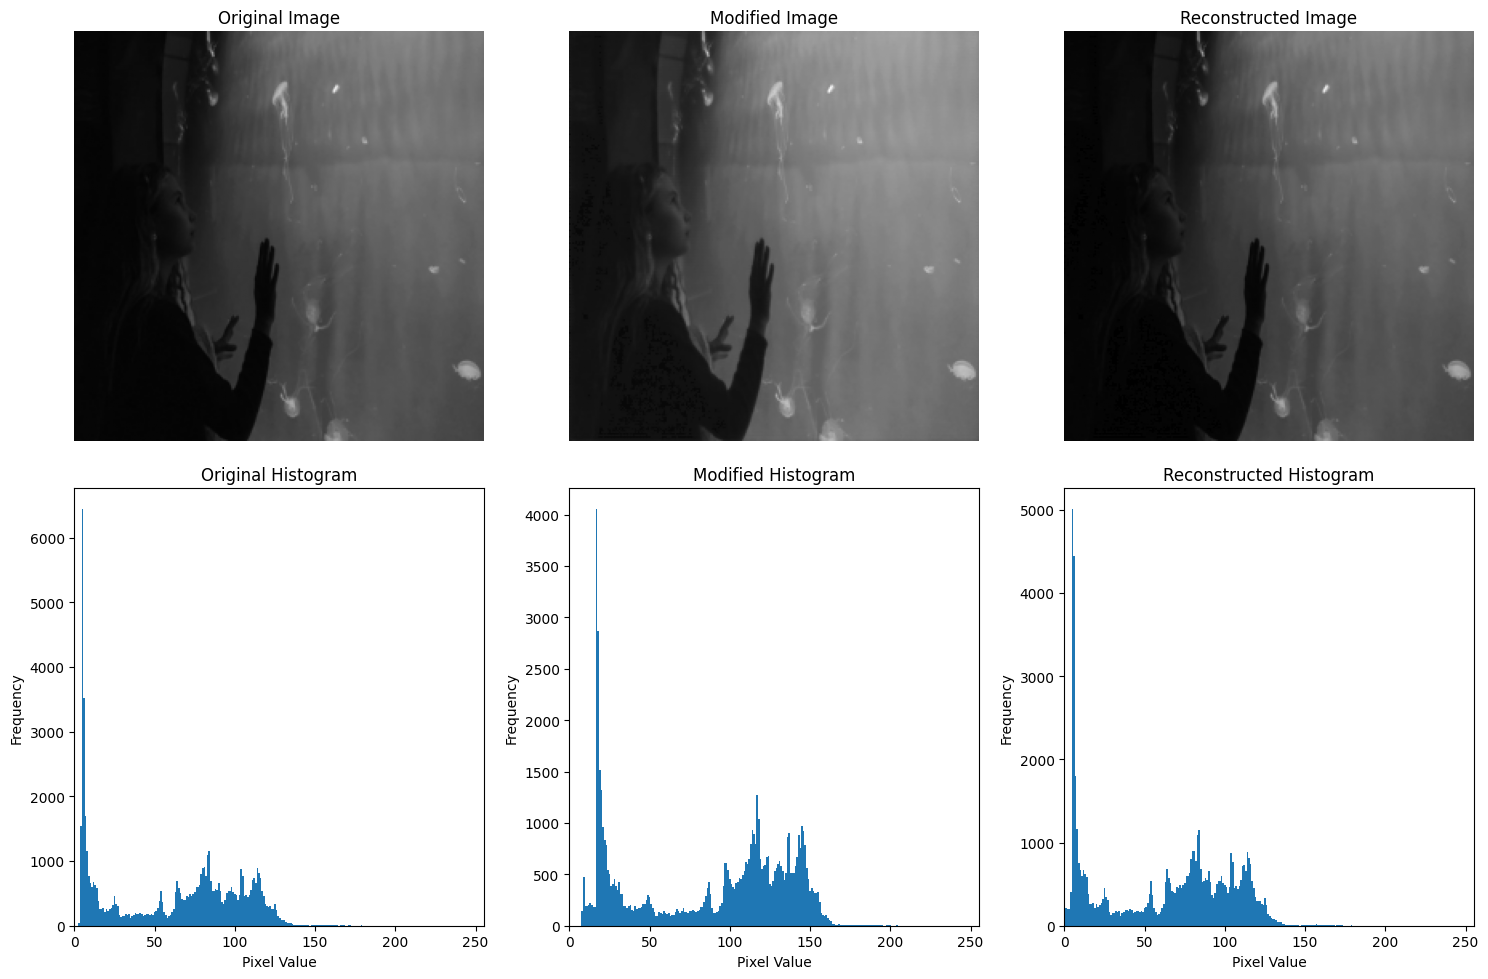

In [ ]:
# prompt: give a testing script which gives histograms and psnr for original modified and reverse for a single image from path and load state for model

import numpy as np
import matplotlib.pyplot as plt

def test_image_reversibility(model, image_path, device='cpu'):
    # Load and preprocess the image
    original_image = read_image(image_path).to(torch.float32)
    original_image = transform(original_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Ensure image dimensions are suitable for squeezing (even height and width)
    B, C, H, W = original_image.shape
    if H % 2 != 0 or W % 2 != 0:
        print(f"Image dimensions {H}x{W} are not even. Resizing to even dimensions.")
        new_h = H - (H % 2)
        new_w = W - (W % 2)
        resize_transform = T.Resize((new_h, new_w), antialias=True)
        original_image = resize_transform(original_image)
        B, C, H, W = original_image.shape # Update dimensions

    print(f"Testing image with dimensions: {H}x{W}")


    # Forward pass
    with torch.no_grad():
        modified_image = model(original_image)
        modified_hist = get_normal_histogram(modified_image)

        max =torch.max(modified_image)
        print(torch.max(modified_image))
        print(torch.min(modified_image))
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_image = 0 + ((255/max)*modified_image)
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        print(torch.max(modified_image))
        print(torch.min(modified_image))

        # modified_image = modified_image-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_hist = get_normal_histogram(modified_image)
        main,left,right = find_histogram_peaks(modified_hist)
        print(f"Main Peak: {main}, Left Peak: {left}, Right Peak: {right}")
        print(modified_hist[main])
        print(modified_hist[left])
        print(modified_hist[right])
        modified_image = torch.where(modified_image <= main, modified_image - 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image + 7, modified_image)
        # right=right+7
        # left= left-7
        # main = main - 7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        # Embed Here
        b = torch.randint(1, 8, (20000,))
        # print(f"Generated stream 'b':\n{b}")
        print(modified_image.shape)
        i=0
        rows, cols = modified_image.shape[2], modified_image.shape[3]
        for r in range (rows):
          for c in range (cols):
            if i < len(b) and int(round(modified_image[0,0,r,c].item()))== (main-7):
              bit_integer = b[i].item()
              i+=1

              modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+bit_integer])

        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== right:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-bit_integer])

# #recovery
        # recovered_bits_left = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= left and modified_image[0,0,r,c]<=(left+7):
        #       recovered_bits_left.append(int(round(modified_image[0,0,r,c].item()-left)))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-int(round(modified_image[0,0,r,c].item()-left))])
        # print(recovered_bits_left)
        # recovered_bits_right = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= right-7 and modified_image[0,0,r,c]<=right:
        #       recovered_bits_right.append(int(round(right-modified_image[0,0,r,c].item())))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+int(round(right-modified_image[0,0,r,c].item()))])
        # print(recovered_bits_right)
        # print(len(recovered_bits_left)+len(recovered_bits_right))
        # modified_image = torch.where(modified_image <= left, modified_image + 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image - 7, modified_image)
        # modified_image = modified_image + 7

    # Inverse pass
    with torch.no_grad():
        modified_image = (max*modified_image)/255
        reconstructed_image = model.inverse(modified_image)

    # --- Calculate PSNR ---
    psnr_modified = calculate_psnr(original_image, modified_image)
    psnr_reconstructed = calculate_psnr(original_image, reconstructed_image)

    print(f"PSNR (Original vs Modified): {psnr_modified:.2f} dB")
    print(f"PSNR (Original vs Reconstructed): {psnr_reconstructed:.2f} dB")
    print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
    print(f"SSIM (Original vs Reconstructed): {ssim(original_image, reconstructed_image):.4f}")

    # --- Generate Histograms ---
    hist_original = get_normal_histogram(original_image)
    hist_modified = get_normal_histogram(modified_image)
    hist_reconstructed = get_normal_histogram(reconstructed_image)

    # --- Plotting ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Images
    axes[0, 0].imshow(original_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(modified_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title('Modified Image')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(reconstructed_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title('Reconstructed Image')
    axes[0, 2].axis('off')

    # Histograms
    bin_edges = np.linspace(0, 256, 257) # Edges for 256 bins from 0 to 256
    axes[1, 0].bar(bin_edges[:-1], hist_original, width=1, edgecolor='none')
    axes[1, 0].set_title('Original Histogram')
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim([0, 255])

    axes[1, 1].bar(bin_edges[:-1], hist_modified, width=1, edgecolor='none')
    axes[1, 1].set_title('Modified Histogram')
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 255])


    axes[1, 2].bar(bin_edges[:-1], hist_reconstructed, width=1, edgecolor='none')
    axes[1, 2].set_title('Reconstructed Histogram')
    axes[1, 2].set_xlabel('Pixel Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Instantiate the model
model = SqueezeNetWrapper()

# Define the path to your saved model state_dict
model_state_path = '/content/checkpoint_epoch_one_side_40.pth' # Replace with the actual path
# CHECKPOINT_PATH = '/content/checkpoint_epoch_100 (1).pth'
# checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
# Load the model state dictionary
try:
    model.load_state_dict(torch.load(model_state_path, map_location='cpu'))
    print(f"Model state loaded successfully from {model_state_path}")
except FileNotFoundError:
    print(f"Error: Model state file not found at {model_state_path}. Please provide the correct path.")
    # You might want to exit or handle this case differently
    exit()
except Exception as e:
    print(f"An error occurred while loading model state: {e}")
    exit()
# try:
#     model.load_state_dict(checkpoint['model_state_dict'])
#     print(f"Model state loaded successfully from {CHECKPOINT_PATH}",)
# except FileNotFoundError:
#     print(f"Error: Model state file not found at {CHECKPOINT_PATH}. Please provide the correct path.")
#     # You might want to exit or handle this case differently
#     exit()
# except Exception as e:
#     print(f"An error occurred while loading model state: {e}")
#     exit()


# Move model to the appropriate device (GPU if available)
device = torch.device("cpu")
print(f"Using device: {device}")
model.to(device)
model.eval() # Set the model to evaluation mode

# Define the path to the image you want to test
image_to_test_path = '/content/ILSVRC2017_test_00005242.JPEG' # Replace with the path to your test image

# Run the testing script
# Make sure 'test_image.png' exists or replace it with a valid image path
if os.path.exists(image_to_test_path):
    test_image_reversibility(model, image_to_test_path, device=device)
else:
    print(f"Error: Test image not found at {image_to_test_path}. Please provide a valid image path.")

In [ ]:
# prompt: give a testing script which gives histograms and psnr for original modified and reverse for a single image from path and load state for model

import numpy as np
import matplotlib.pyplot as plt

def test_image_reversibility(model, image_path, device='cpu'):
    # Load and preprocess the image
    original_image = read_image(image_path).to(torch.float32)
    original_image = transform(original_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Ensure image dimensions are suitable for squeezing (even height and width)
    B, C, H, W = original_image.shape
    if H % 2 != 0 or W % 2 != 0:
        print(f"Image dimensions {H}x{W} are not even. Resizing to even dimensions.")
        new_h = H - (H % 2)
        new_w = W - (W % 2)
        resize_transform = T.Resize((new_h, new_w), antialias=True)
        original_image = resize_transform(original_image)
        B, C, H, W = original_image.shape # Update dimensions

    print(f"Testing image with dimensions: {H}x{W}")


    # Forward pass
    with torch.no_grad():
        modified_image = model(original_image)
        modified_hist = get_normal_histogram(modified_image)

        max =torch.max(modified_image)
        print(torch.max(modified_image))
        print(torch.min(modified_image))
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_image = 0 + ((255/max)*modified_image)
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        print(torch.max(modified_image))
        print(torch.min(modified_image))

        modified_image = modified_image-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_hist = get_normal_histogram(modified_image)
        main,left,right = find_histogram_peaks(modified_hist)
        print(f"Main Peak: {main}, Left Peak: {left}, Right Peak: {right}")
        print(modified_hist[main])
        print(modified_hist[left])
        print(modified_hist[right])
        modified_image = torch.where(modified_image <= left, modified_image - 7, modified_image)
        modified_image = torch.where(modified_image >= right, modified_image + 7, modified_image)
        right=right+7
        left= left-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        # Embed Here
        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== left:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+bit_integer])

        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== right:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-bit_integer])

# #recovery
        # recovered_bits_left = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= left and modified_image[0,0,r,c]<=(left+7):
        #       recovered_bits_left.append(int(round(modified_image[0,0,r,c].item()-left)))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-int(round(modified_image[0,0,r,c].item()-left))])
        # print(recovered_bits_left)
        # recovered_bits_right = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= right-7 and modified_image[0,0,r,c]<=right:
        #       recovered_bits_right.append(int(round(right-modified_image[0,0,r,c].item())))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+int(round(right-modified_image[0,0,r,c].item()))])
        # print(recovered_bits_right)
        # print(len(recovered_bits_left)+len(recovered_bits_right))
        # modified_image = torch.where(modified_image <= left, modified_image + 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image - 7, modified_image)
        # modified_image = modified_image + 7

    # Inverse pass
    with torch.no_grad():
        modified_image = (max*modified_image)/255
        reconstructed_image = model.inverse(modified_image)

    # --- Calculate PSNR ---
    psnr_modified = calculate_psnr(original_image, modified_image)
    psnr_reconstructed = calculate_psnr(original_image, reconstructed_image)

    print(f"PSNR (Original vs Modified): {psnr_modified:.2f} dB")
    print(f"PSNR (Original vs Reconstructed): {psnr_reconstructed:.2f} dB")
    print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
    print(f"SSIM (Original vs Reconstructed): {ssim(original_image, reconstructed_image):.4f}")

    # --- Generate Histograms ---
    hist_original = get_normal_histogram(original_image)
    hist_modified = get_normal_histogram(modified_image)
    hist_reconstructed = get_normal_histogram(reconstructed_image)

    # --- Plotting ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Images
    axes[0, 0].imshow(original_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(modified_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title('Modified Image')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(reconstructed_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title('Reconstructed Image')
    axes[0, 2].axis('off')

    # Histograms
    bin_edges = np.linspace(0, 256, 257) # Edges for 256 bins from 0 to 256
    axes[1, 0].bar(bin_edges[:-1], hist_original, width=1, edgecolor='none')
    axes[1, 0].set_title('Original Histogram')
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim([0, 255])

    axes[1, 1].bar(bin_edges[:-1], hist_modified, width=1, edgecolor='none')
    axes[1, 1].set_title('Modified Histogram')
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 255])


    axes[1, 2].bar(bin_edges[:-1], hist_reconstructed, width=1, edgecolor='none')
    axes[1, 2].set_title('Reconstructed Histogram')
    axes[1, 2].set_xlabel('Pixel Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Instantiate the model
model = SqueezeNetWrapper()

# Define the path to your saved model state_dict
# model_state_path = '/content/checkpoint_epoch_60.pth' # Replace with the actual path
CHECKPOINT_PATH = '/content/checkpoint_epoch_60.pth'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
# Load the model state dictionary
try:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model state loaded successfully from {CHECKPOINT_PATH}",)
except FileNotFoundError:
    print(f"Error: Model state file not found at {CHECKPOINT_PATH}. Please provide the correct path.")
    # You might want to exit or handle this case differently
    exit()
except Exception as e:
    print(f"An error occurred while loading model state: {e}")
    exit()


# Move model to the appropriate device (GPU if available)
device = torch.device("cpu")
print(f"Using device: {device}")
model.to(device)
model.eval() # Set the model to evaluation mode

# Define the path to the image you want to test
image_to_test_path = '/content/ILSVRC2017_test_00005135.JPEG' # Replace with the path to your test image

# Run the testing script
# Make sure 'test_image.png' exists or replace it with a valid image path
if os.path.exists(image_to_test_path):
    test_image_reversibility(model, image_to_test_path, device=device)
else:
    print(f"Error: Test image not found at {image_to_test_path}. Please provide a valid image path.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/checkpoint_epoch_60.pth'

In [ ]:
# prompt: give a testing script which gives histograms and psnr for original modified and reverse for a single image from path and load state for model

import numpy as np
import matplotlib.pyplot as plt

def test_image_reversibility(model, image_path, device='cpu'):
    # Load and preprocess the image
    original_image = read_image(image_path).to(torch.float32)
    original_image = transform(original_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Ensure image dimensions are suitable for squeezing (even height and width)
    B, C, H, W = original_image.shape
    if H % 2 != 0 or W % 2 != 0:
        print(f"Image dimensions {H}x{W} are not even. Resizing to even dimensions.")
        new_h = H - (H % 2)
        new_w = W - (W % 2)
        resize_transform = T.Resize((new_h, new_w), antialias=True)
        original_image = resize_transform(original_image)
        B, C, H, W = original_image.shape # Update dimensions

    print(f"Testing image with dimensions: {H}x{W}")


    # Forward pass
    with torch.no_grad():
        modified_image = model(original_image)
        modified_hist = get_normal_histogram(modified_image)

        max =torch.max(modified_image)
        print(torch.max(modified_image))
        print(torch.min(modified_image))
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_image = 0 + ((255/max)*modified_image)
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        print(torch.max(modified_image))
        print(torch.min(modified_image))

        modified_image = modified_image-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_hist = get_normal_histogram(modified_image)
        main,left,right = find_histogram_peaks(modified_hist)
        print(f"Main Peak: {main}, Left Peak: {left}, Right Peak: {right}")
        print(modified_hist[main])
        print(modified_hist[left])
        print(modified_hist[right])
        # modified_image = torch.where(modified_image <= left, modified_image - 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image + 7, modified_image)
        # right=right+7
        # left= left-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        # Embed Here
        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== left:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+bit_integer])

        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== right:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-bit_integer])

# #recovery
        # recovered_bits_left = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= left and modified_image[0,0,r,c]<=(left+7):
        #       recovered_bits_left.append(int(round(modified_image[0,0,r,c].item()-left)))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-int(round(modified_image[0,0,r,c].item()-left))])
        # print(recovered_bits_left)
        # recovered_bits_right = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= right-7 and modified_image[0,0,r,c]<=right:
        #       recovered_bits_right.append(int(round(right-modified_image[0,0,r,c].item())))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+int(round(right-modified_image[0,0,r,c].item()))])
        # print(recovered_bits_right)
        # print(len(recovered_bits_left)+len(recovered_bits_right))
        # modified_image = torch.where(modified_image <= left, modified_image + 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image - 7, modified_image)
        # modified_image = modified_image + 7

    # Inverse pass
    with torch.no_grad():
        modified_image = (max*modified_image)/255
        reconstructed_image = model.inverse(modified_image)

    # --- Calculate PSNR ---
    psnr_modified = calculate_psnr(original_image, modified_image)
    psnr_reconstructed = calculate_psnr(original_image, reconstructed_image)

    print(f"PSNR (Original vs Modified): {psnr_modified:.2f} dB")
    print(f"PSNR (Original vs Reconstructed): {psnr_reconstructed:.2f} dB")
    print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
    print(f"SSIM (Original vs Reconstructed): {ssim(original_image, reconstructed_image):.4f}")

    # --- Generate Histograms ---
    hist_original = get_normal_histogram(original_image)
    hist_modified = get_normal_histogram(modified_image)
    hist_reconstructed = get_normal_histogram(reconstructed_image)

    # --- Plotting ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Images
    axes[0, 0].imshow(original_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(modified_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title('Modified Image')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(reconstructed_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title('Reconstructed Image')
    axes[0, 2].axis('off')

    # Histograms
    bin_edges = np.linspace(0, 256, 257) # Edges for 256 bins from 0 to 256
    axes[1, 0].bar(bin_edges[:-1], hist_original, width=1, edgecolor='none')
    axes[1, 0].set_title('Original Histogram')
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim([0, 255])

    axes[1, 1].bar(bin_edges[:-1], hist_modified, width=1, edgecolor='none')
    axes[1, 1].set_title('Modified Histogram')
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 255])


    axes[1, 2].bar(bin_edges[:-1], hist_reconstructed, width=1, edgecolor='none')
    axes[1, 2].set_title('Reconstructed Histogram')
    axes[1, 2].set_xlabel('Pixel Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Instantiate the model
model = SqueezeNetWrapper()

# Define the path to your saved model state_dict
# model_state_path = '/content/checkpoint_epoch_60.pth' # Replace with the actual path
CHECKPOINT_PATH = '/content/checkpoint_epoch_60.pth'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
# Load the model state dictionary
try:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model state loaded successfully from {CHECKPOINT_PATH}",)
except FileNotFoundError:
    print(f"Error: Model state file not found at {CHECKPOINT_PATH}. Please provide the correct path.")
    # You might want to exit or handle this case differently
    exit()
except Exception as e:
    print(f"An error occurred while loading model state: {e}")
    exit()


# Move model to the appropriate device (GPU if available)
device = torch.device("cpu")
print(f"Using device: {device}")
model.to(device)
model.eval() # Set the model to evaluation mode

# Define the path to the image you want to test
image_to_test_path = '/content/ILSVRC2017_test_00005135.JPEG' # Replace with the path to your test image

# Run the testing script
# Make sure 'test_image.png' exists or replace it with a valid image path
if os.path.exists(image_to_test_path):
    test_image_reversibility(model, image_to_test_path, device=device)
else:
    print(f"Error: Test image not found at {image_to_test_path}. Please provide a valid image path.")

In [ ]:
# prompt: give a testing script which gives histograms and psnr for original modified and reverse for a single image from path and load state for model

import numpy as np
import matplotlib.pyplot as plt

def test_image_reversibility(model, image_path, device='cpu'):
    # Load and preprocess the image
    original_image = read_image(image_path).to(torch.float32)
    original_image = transform(original_image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Ensure image dimensions are suitable for squeezing (even height and width)
    B, C, H, W = original_image.shape
    if H % 2 != 0 or W % 2 != 0:
        print(f"Image dimensions {H}x{W} are not even. Resizing to even dimensions.")
        new_h = H - (H % 2)
        new_w = W - (W % 2)
        resize_transform = T.Resize((new_h, new_w), antialias=True)
        original_image = resize_transform(original_image)
        B, C, H, W = original_image.shape # Update dimensions

    print(f"Testing image with dimensions: {H}x{W}")


    # Forward pass
    with torch.no_grad():
        modified_image = model(original_image)
        modified_hist = get_normal_histogram(modified_image)

        max =torch.max(modified_image)
        print(torch.max(modified_image))
        print(torch.min(modified_image))
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_image = 0 + ((255/max)*modified_image)
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        print(torch.max(modified_image))
        print(torch.min(modified_image))

        # modified_image = modified_image-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        modified_hist = get_normal_histogram(modified_image)
        main,left,right = find_histogram_peaks(modified_hist)
        print(f"Main Peak: {main}, Left Peak: {left}, Right Peak: {right}")
        print(modified_hist[main])
        print(modified_hist[left])
        print(modified_hist[right])
        # modified_image = torch.where(modified_image <= left, modified_image - 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image + 7, modified_image)
        # right=right+7
        # left= left-7
        print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
        # Embed Here
        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== left:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+bit_integer])

        # b = torch.randint(1, 8, (20000,))
        # # print(f"Generated stream 'b':\n{b}")
        # print(modified_image.shape)
        # i=0
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if i < len(b) and int(round(modified_image[0,0,r,c].item()))== right:
        #       bit_integer = b[i].item()
        #       i+=1

        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-bit_integer])

# #recovery
        # recovered_bits_left = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= left and modified_image[0,0,r,c]<=(left+7):
        #       recovered_bits_left.append(int(round(modified_image[0,0,r,c].item()-left)))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()-int(round(modified_image[0,0,r,c].item()-left))])
        # print(recovered_bits_left)
        # recovered_bits_right = []
        # rows, cols = modified_image.shape[2], modified_image.shape[3]
        # for r in range (rows):
        #   for c in range (cols):
        #     if modified_image[0,0,r,c].item()>= right-7 and modified_image[0,0,r,c]<=right:
        #       recovered_bits_right.append(int(round(right-modified_image[0,0,r,c].item())))
        #       modified_image[0,0,r,c]= torch.tensor([modified_image[0,0,r,c].item()+int(round(right-modified_image[0,0,r,c].item()))])
        # print(recovered_bits_right)
        # print(len(recovered_bits_left)+len(recovered_bits_right))
        # modified_image = torch.where(modified_image <= left, modified_image + 7, modified_image)
        # modified_image = torch.where(modified_image >= right, modified_image - 7, modified_image)
        # modified_image = modified_image + 7

    # Inverse pass
    with torch.no_grad():
        modified_image = (max*modified_image)/255
        reconstructed_image = model.inverse(modified_image)

    # --- Calculate PSNR ---
    psnr_modified = calculate_psnr(original_image, modified_image)
    psnr_reconstructed = calculate_psnr(original_image, reconstructed_image)

    print(f"PSNR (Original vs Modified): {psnr_modified:.2f} dB")
    print(f"PSNR (Original vs Reconstructed): {psnr_reconstructed:.2f} dB")
    print(f"SSIM (Original vs Modified): {ssim(original_image, modified_image):.4f}")
    print(f"SSIM (Original vs Reconstructed): {ssim(original_image, reconstructed_image):.4f}")

    # --- Generate Histograms ---
    hist_original = get_normal_histogram(original_image)
    hist_modified = get_normal_histogram(modified_image)
    hist_reconstructed = get_normal_histogram(reconstructed_image)

    # --- Plotting ---
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Images
    axes[0, 0].imshow(original_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')

    axes[0, 1].imshow(modified_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title('Modified Image')
    axes[0, 1].axis('off')

    axes[0, 2].imshow(reconstructed_image.squeeze().cpu().numpy(), cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title('Reconstructed Image')
    axes[0, 2].axis('off')

    # Histograms
    bin_edges = np.linspace(0, 256, 257) # Edges for 256 bins from 0 to 256
    axes[1, 0].bar(bin_edges[:-1], hist_original, width=1, edgecolor='none')
    axes[1, 0].set_title('Original Histogram')
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_xlim([0, 255])

    axes[1, 1].bar(bin_edges[:-1], hist_modified, width=1, edgecolor='none')
    axes[1, 1].set_title('Modified Histogram')
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_xlim([0, 255])


    axes[1, 2].bar(bin_edges[:-1], hist_reconstructed, width=1, edgecolor='none')
    axes[1, 2].set_title('Reconstructed Histogram')
    axes[1, 2].set_xlabel('Pixel Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].set_xlim([0, 255])

    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Instantiate the model
model = SqueezeNetWrapper()

# Define the path to your saved model state_dict
# model_state_path = '/content/checkpoint_epoch_60.pth' # Replace with the actual path
CHECKPOINT_PATH = '/content/checkpoint_epoch_60.pth'
checkpoint = torch.load(CHECKPOINT_PATH, map_location=torch.device('cpu'))
# Load the model state dictionary
try:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Model state loaded successfully from {CHECKPOINT_PATH}",)
except FileNotFoundError:
    print(f"Error: Model state file not found at {CHECKPOINT_PATH}. Please provide the correct path.")
    # You might want to exit or handle this case differently
    exit()
except Exception as e:
    print(f"An error occurred while loading model state: {e}")
    exit()


# Move model to the appropriate device (GPU if available)
device = torch.device("cpu")
print(f"Using device: {device}")
model.to(device)
model.eval() # Set the model to evaluation mode

# Define the path to the image you want to test
image_to_test_path = '/content/ILSVRC2017_test_00005135.JPEG' # Replace with the path to your test image

# Run the testing script
# Make sure 'test_image.png' exists or replace it with a valid image path
if os.path.exists(image_to_test_path):
    test_image_reversibility(model, image_to_test_path, device=device)
else:
    print(f"Error: Test image not found at {image_to_test_path}. Please provide a valid image path.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')